In [1]:
import os
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

/Users/nassimazzouzi/anaconda3/envs/ml_iris/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


In [3]:
path = kagglehub.dataset_download("uciml/iris")
print("Path to dataset files:", path)

Path to dataset files: /Users/nassimazzouzi/.cache/kagglehub/datasets/uciml/iris/versions/2


In [4]:
csv_path = "/Users/nassimazzouzi/.cache/kagglehub/datasets/uciml/iris/versions/2/Iris.csv"
df=pd.read_csv(csv_path)

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


We have to clean the data right now

In [7]:
#check missiing values
df.isnull().sum()
#the id column is unecessary and can lead to data leakage (e.g if id<=50 -> this type of flower)
df_clean = df.drop(columns=["Id"])
#Predictors
X = df_clean.drop(columns=["Species"])
#species to be predicted
y = df_clean["Species"]

print("Dimensions de X (lignes, colonnes) :", X.shape)
print("Dimensions de y :", y.shape)
X.head()

Dimensions de X (lignes, colonnes) : (150, 4)
Dimensions de y : (150,)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
#Split the data into Train/Test
#Breakdown: 80% for learning (Train), 20% for testing (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Creation and training of the decision tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

print("Trained with success !")

Trained with success !


In [10]:
#Generate predictions on the test set
y_pred = clf.predict(X_test)

#Compute evaluation metrics (Accuracy & Classification Report)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

Accuracy: 96.67%

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



#Reminder for me
Accuracy: "How often is the model right overall?" It is the percentage of total correct predictions across all classes.

Precision: "When it claims yes, is it really yes?" It measures reliability by penalizing false alarms (false positives).

Recall: "Did it find all the targets?" It measures coverage by penalizing missed cases (false negatives).

F1-Score: "The balanced score." It is the harmonic mean of Precision and Recall, showing how well the model balances false alarms and missed targets.

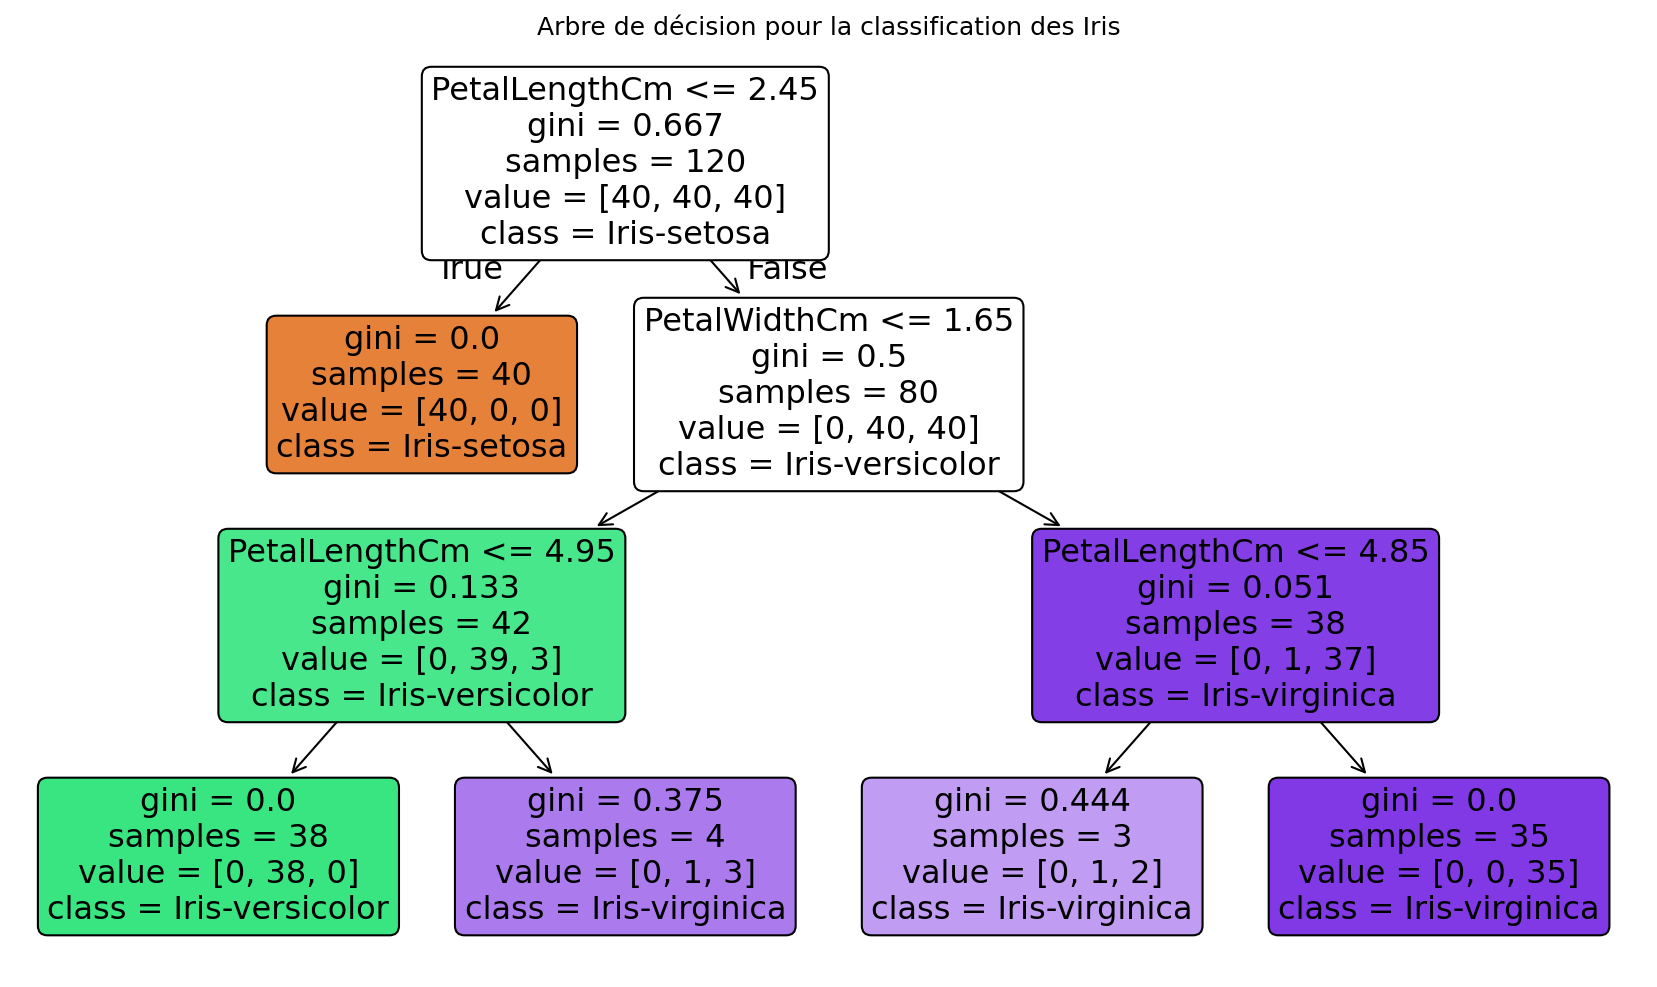

In [11]:
#Decision Tree
plt.figure(figsize=(14, 8), dpi=150)
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True
)
plt.title("Arbre de décision pour la classification des Iris")
plt.show()